# LightGBM Quantile Regression — GB Day-Ahead Price Forecasting

This notebook trains **global direct LightGBM quantile regression** models for raw half-hourly GB day-ahead power prices.

**Approach**
- One LightGBM model per quantile: Q01, Q05, Q10, Q25, Q50, Q75, Q90, Q95, Q99
- Rolling-origin backtest: expanding training window, 1-month val + 1-month test, roll by 1 month
- Benchmark: lag-1 day same-period price (`price_lag1d`)
- Evaluation: point (MAE/RMSE), probabilistic (pinball, coverage, width), marginal PIT calibration, shape diagnostics


In [23]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [24]:
# ── Configuration ────────────────────────────────────────────────────────────

DATA_PATH = Path("data/processed/features_v1.parquet")

FEATURES = [
    "settlement_period",
    "month",
    "is_weekend",
    "weekday",
    "price_lag1d",
    "price_lag7d",
    "price_roll7d_mean",
    "net_load",
    "drm_eve_mean",
    "drm_min",
    "lolp_max",
]
CAT_FEATURES = ["settlement_period", "month", "weekday"]
TARGET = "price"

QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
Q_COLS    = [f"pred_q{int(q*100):02d}" for q in QUANTILES]

BASE_PARAMS = {
    "objective":        "quantile",
    "metric":           "quantile",
    "boosting_type":    "gbdt",
    "learning_rate":    0.05,
    "n_estimators":     2000,
    "num_leaves":       31,
    "max_depth":        6,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq":     1,
    "lambda_l1":        0.0,
    "lambda_l2":        2.0,
    "seed":             42,
    "verbosity":        -1,
}

INITIAL_TRAIN_MONTHS = 12   # burn-in period
VAL_MONTHS           = 1
TEST_MONTHS          = 1

In [25]:
# ── Load & validate data ──────────────────────────────────────────────────────

df = pd.read_parquet(DATA_PATH)
df["settlement_date"] = pd.to_datetime(df["settlement_date"])
df = df.sort_values(["settlement_date", "settlement_period"]).reset_index(drop=True)

print(f"Shape:      {df.shape}")
print(f"Date range: {df['settlement_date'].min().date()} → {df['settlement_date'].max().date()}")
print(f"Unique dates: {df['settlement_date'].nunique()}")
print()
print("Dtypes:")
print(df[FEATURES + [TARGET]].dtypes)
print()
print("Missingness per feature:")
miss = df[FEATURES + [TARGET]].isnull().sum()
miss_pct = miss / len(df) * 100
print(pd.DataFrame({"null_count": miss, "null_pct": miss_pct.round(2)}))

Shape:      (54864, 13)
Date range: 2023-01-08 → 2026-03-01
Unique dates: 1143

Dtypes:
settlement_period      int32
month                  int32
is_weekend             int32
weekday                int32
price_lag1d          float64
price_lag7d          float64
price_roll7d_mean    float64
net_load             float64
drm_eve_mean         float64
drm_min              float64
lolp_max             float64
price                float64
dtype: object

Missingness per feature:
                   null_count  null_pct
settlement_period           0       0.0
month                       0       0.0
is_weekend                  0       0.0
weekday                     0       0.0
price_lag1d                 0       0.0
price_lag7d                 0       0.0
price_roll7d_mean           0       0.0
net_load                    0       0.0
drm_eve_mean                0       0.0
drm_min                     0       0.0
lolp_max                    0       0.0
price                       0       0.0


In [26]:
# ── Build backtest folds ──────────────────────────────────────────────────────

def make_folds(df, initial_train_months=12, val_months=1, test_months=1):
    """
    Expanding-window rolling-origin folds.

    Returns list of (train_mask, val_mask, test_mask) boolean arrays.
    All windows are strictly non-overlapping in the val/test dimension.
    """
    dates = df["settlement_date"]
    start = dates.min()

    # First train window ends after initial_train_months
    first_val_start = start + pd.DateOffset(months=initial_train_months)

    folds = []
    val_start = first_val_start

    while True:
        val_end  = val_start  + pd.DateOffset(months=val_months)
        test_end = val_end    + pd.DateOffset(months=test_months)

        if test_end > dates.max() + pd.Timedelta(days=1):
            break

        train_mask = dates < val_start
        val_mask   = (dates >= val_start) & (dates < val_end)
        test_mask  = (dates >= val_end)   & (dates < test_end)

        folds.append((train_mask, val_mask, test_mask))
        val_start = val_start + pd.DateOffset(months=1)

    return folds


folds = make_folds(df, INITIAL_TRAIN_MONTHS, VAL_MONTHS, TEST_MONTHS)
print(f"Total folds: {len(folds)}\n")

for i, (tr, va, te) in enumerate(folds):
    tr_dates = df.loc[tr, "settlement_date"]
    va_dates = df.loc[va, "settlement_date"]
    te_dates = df.loc[te, "settlement_date"]
    print(
        f"Fold {i+1:2d} | "
        f"train {tr_dates.min().date()} → {tr_dates.max().date()} ({tr.sum()//48:3d}d) | "
        f"val   {va_dates.min().date()} → {va_dates.max().date()} ({va.sum()//48:2d}d) | "
        f"test  {te_dates.min().date()} → {te_dates.max().date()} ({te.sum()//48:2d}d)"
    )

Total folds: 24

Fold  1 | train 2023-01-08 → 2024-01-07 (363d) | val   2024-01-08 → 2024-02-07 (31d) | test  2024-02-08 → 2024-03-07 (29d)
Fold  2 | train 2023-01-08 → 2024-02-07 (394d) | val   2024-02-08 → 2024-03-07 (29d) | test  2024-03-08 → 2024-04-07 (30d)
Fold  3 | train 2023-01-08 → 2024-03-07 (423d) | val   2024-03-08 → 2024-04-07 (30d) | test  2024-04-08 → 2024-05-07 (30d)
Fold  4 | train 2023-01-08 → 2024-04-07 (453d) | val   2024-04-08 → 2024-05-07 (30d) | test  2024-05-08 → 2024-06-07 (31d)
Fold  5 | train 2023-01-08 → 2024-05-07 (483d) | val   2024-05-08 → 2024-06-07 (31d) | test  2024-06-08 → 2024-07-07 (30d)
Fold  6 | train 2023-01-08 → 2024-06-07 (514d) | val   2024-06-08 → 2024-07-07 (30d) | test  2024-07-08 → 2024-08-07 (31d)
Fold  7 | train 2023-01-08 → 2024-07-07 (544d) | val   2024-07-08 → 2024-08-07 (31d) | test  2024-08-08 → 2024-09-07 (31d)
Fold  8 | train 2023-01-08 → 2024-08-07 (575d) | val   2024-08-08 → 2024-09-07 (31d) | test  2024-09-08 → 2024-10-07 (30d)

In [27]:
# ── Training helpers ────────────────────────────────────────────────────────

def train_quantile_models(X_train, y_train, X_val, y_val):
    """
    Train one LightGBM model per quantile with early stopping on the val set.
    Returns dict {q: booster} and dict {q: best_iteration}.
    """
    dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=CAT_FEATURES, free_raw_data=False)
    dval   = lgb.Dataset(X_val,   label=y_val,   categorical_feature=CAT_FEATURES, reference=dtrain, free_raw_data=False)

    models    = {}
    best_iters = {}

    for q in QUANTILES:
        params = {**BASE_PARAMS, "alpha": q}
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),   # silence per-round logging
        ]
        booster = lgb.train(
            params,
            dtrain,
            num_boost_round=BASE_PARAMS["n_estimators"],
            valid_sets=[dval],
            callbacks=callbacks,
        )
        models[q]     = booster
        best_iters[q] = booster.best_iteration

    return models, best_iters


# ── Main backtest loop ────────────────────────────────────────────────────────

all_preds = []

for fold_idx, (tr, va, te) in enumerate(folds):
    X_train = df.loc[tr, FEATURES]
    y_train = df.loc[tr, TARGET]
    X_val   = df.loc[va, FEATURES]
    y_val   = df.loc[va, TARGET]
    X_test  = df.loc[te, FEATURES]

    print(f"Fold {fold_idx+1}/{len(folds)} — training {len(QUANTILES)} quantile models ...", end=" ", flush=True)
    models, best_iters = train_quantile_models(X_train, y_train, X_val, y_val)
    print(f"done  (best iters: {[best_iters[q] for q in QUANTILES]})")

    # Collect test predictions
    fold_df = df.loc[te, ["settlement_date", "settlement_period", TARGET, "price_lag1d"]].copy()
    fold_df = fold_df.rename(columns={TARGET: "actual_price", "price_lag1d": "naive_forecast"})

    for q, col in zip(QUANTILES, Q_COLS):
        fold_df[col] = models[q].predict(X_test)

    # ── Naive residual intervals ──────────────────────────────────────────────
    # Residuals from the training set only (strictly pre-test information)
    train_residuals = (df.loc[tr, TARGET] - df.loc[tr, "price_lag1d"]).values
    for q, pred_col in zip(QUANTILES, Q_COLS):
        naive_col = pred_col.replace("pred_", "naive_")
        fold_df[naive_col] = fold_df["naive_forecast"] + np.quantile(train_residuals, q)

    all_preds.append(fold_df)

print(f"\nBacktest complete — {len(folds)} folds.")


Fold 1/24 — training 9 quantile models ... done  (best iters: [87, 48, 24, 25, 41, 56, 1686, 2000, 2000])
Fold 2/24 — training 9 quantile models ... done  (best iters: [54, 25, 8, 22, 40, 167, 602, 2000, 2000])
Fold 3/24 — training 9 quantile models ... done  (best iters: [97, 70, 127, 156, 141, 316, 1450, 1792, 2000])
Fold 4/24 — training 9 quantile models ... done  (best iters: [153, 90, 64, 81, 99, 165, 530, 473, 1656])
Fold 5/24 — training 9 quantile models ... done  (best iters: [179, 75, 99, 259, 73, 68, 70, 112, 391])
Fold 6/24 — training 9 quantile models ... done  (best iters: [77, 90, 185, 232, 146, 89, 505, 562, 525])
Fold 7/24 — training 9 quantile models ... done  (best iters: [120, 60, 38, 29, 79, 95, 1007, 1032, 2000])
Fold 8/24 — training 9 quantile models ... done  (best iters: [57, 140, 217, 146, 225, 133, 338, 496, 404])
Fold 9/24 — training 9 quantile models ... done  (best iters: [142, 79, 76, 49, 27, 73, 403, 477, 492])
Fold 10/24 — training 9 quantile models ... 

In [28]:
# ── Concatenate predictions ───────────────────────────────────────────────────

results_df = pd.concat(all_preds, ignore_index=True)
results_df = results_df.sort_values(["settlement_date", "settlement_period"]).reset_index(drop=True)

print(f"Results shape: {results_df.shape}")
print(f"Date range:    {results_df['settlement_date'].min().date()} → {results_df['settlement_date'].max().date()}")
print(f"Unique dates:  {results_df['settlement_date'].nunique()}")
print()
print(results_df[["settlement_date", "settlement_period", "actual_price", "naive_forecast"] + Q_COLS].head(4))

Results shape: (34896, 22)
Date range:    2024-02-08 → 2026-02-07
Unique dates:  727

  settlement_date  settlement_period  actual_price  naive_forecast   pred_q01  \
0      2024-02-08                  1         61.61           65.07  46.911656   
1      2024-02-08                  2         64.15           69.17  52.448084   
2      2024-02-08                  3         61.23           69.75  46.138139   
3      2024-02-08                  4         55.97           65.99  48.529085   

    pred_q05   pred_q10   pred_q25   pred_q50    pred_q75    pred_q90  \
0  61.583720  62.372452  78.596105  88.122034  105.672646  129.312899   
1  61.393576  63.415655  78.337268  88.253124  107.682117  129.197512   
2  59.139951  63.807624  78.436789  86.412087  103.284091  121.987293   
3  59.862690  62.326761  77.956675  86.784062  103.766013  118.602979   

     pred_q95    pred_q99  
0  150.640941  142.938617  
1  155.198823  146.902770  
2  131.944710  138.121569  
3  129.688935  134.381935  


In [29]:
# ── Quantile crossing analysis ────────────────────────────────────────────────

pred_arr = results_df[Q_COLS].values   # shape (N, 7)

print("Quantile crossing analysis (before correction)")
print("-" * 50)

adjacent_pairs = list(zip(Q_COLS[:-1], Q_COLS[1:]))
any_crossing = np.zeros(len(results_df), dtype=bool)

for lo_col, hi_col in adjacent_pairs:
    mask = results_df[lo_col] > results_df[hi_col]
    any_crossing |= mask.values
    pct = mask.mean() * 100
    print(f"  {lo_col} > {hi_col}: {mask.sum():5d} rows  ({pct:.2f}%)")

print()
print(f"  Rows with ANY crossing: {any_crossing.sum()} ({any_crossing.mean()*100:.2f}%)")

# Enforce non-crossing by row-wise sort
pred_arr_sorted = np.sort(pred_arr, axis=1)
for col, vals in zip(Q_COLS, pred_arr_sorted.T):
    results_df[col] = vals

print("\nQuantile crossing after correction: 0 (row-wise sort applied)")

Quantile crossing analysis (before correction)
--------------------------------------------------
  pred_q01 > pred_q05:   878 rows  (2.52%)
  pred_q05 > pred_q10:  2540 rows  (7.28%)
  pred_q10 > pred_q25:   793 rows  (2.27%)
  pred_q25 > pred_q50:   218 rows  (0.62%)
  pred_q50 > pred_q75:   156 rows  (0.45%)
  pred_q75 > pred_q90:  1605 rows  (4.60%)
  pred_q90 > pred_q95:  3097 rows  (8.87%)
  pred_q95 > pred_q99:  1809 rows  (5.18%)

  Rows with ANY crossing: 9871 (28.29%)

Quantile crossing after correction: 0 (row-wise sort applied)


In [30]:
# ── Point forecast evaluation ─────────────────────────────────────────────────

actual  = results_df["actual_price"].values
p50     = results_df["pred_q50"].values
naive   = results_df["naive_forecast"].values

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

print("Overall point forecast")
print("-" * 40)
print(f"  Model P50 MAE:   {mean_absolute_error(actual, p50):.2f}")
print(f"  Model P50 RMSE:  {rmse(actual, p50):.2f}")
print(f"  Naive  MAE:      {mean_absolute_error(actual, naive):.2f}")
print(f"  Naive  RMSE:     {rmse(actual, naive):.2f}")

# By settlement period
by_sp = results_df.groupby("settlement_period").apply(
    lambda g: pd.Series({
        "model_mae":  mean_absolute_error(g["actual_price"], g["pred_q50"]),
        "naive_mae":  mean_absolute_error(g["actual_price"], g["naive_forecast"]),
    })
).reset_index()

print("\nMAE by settlement period (sample — first & last 5):")
print(pd.concat([by_sp.head(5), by_sp.tail(5)]).to_string(index=False))

# By month
results_df["month"] = results_df["settlement_date"].dt.month
by_month = results_df.groupby("month").apply(
    lambda g: pd.Series({
        "model_mae":  mean_absolute_error(g["actual_price"], g["pred_q50"]),
        "naive_mae":  mean_absolute_error(g["actual_price"], g["naive_forecast"]),
    })
).reset_index()

print("\nMAE by month:")
print(by_month.to_string(index=False))

Overall point forecast
----------------------------------------
  Model P50 MAE:   15.24
  Model P50 RMSE:  26.75
  Naive  MAE:      20.59
  Naive  RMSE:     38.43

MAE by settlement period (sample — first & last 5):
 settlement_period  model_mae  naive_mae
                 1  13.346172  19.045942
                 2  13.564553  18.663329
                 3  13.531296  19.133246
                 4  13.892931  19.267538
                 5  14.004300  19.301719
                44  11.589306  14.119532
                45  11.355692  13.534470
                46  12.358949  15.260041
                47  13.566841  17.599106
                48  14.360789  19.653673

MAE by month:
 month  model_mae  naive_mae
     1  20.920185  27.609580
     2  17.488729  13.579017
     3  16.697828  15.168330
     4  19.073931  21.240177
     5  12.012330  19.303982
     6  16.745123  28.096799
     7  10.716027  15.080827
     8  14.601112  23.159755
     9  13.370192  23.433149
    10  13.979543  22.48114

Pinball loss per quantile
-----------------------------------
  Q01: 0.538
  Q05: 1.914
  Q10: 3.287
  Q25: 6.020
  Q50: 7.618
  Q75: 6.310
  Q90: 3.771
  Q95: 2.434
  Q99: 0.972
  Mean pinball: 3.652

Coverage and average interval width: LightGBM vs naive residual
------------------------------------------------------------------------
Interval   Nominal   LGB cov   LGB width   Naive cov   Naive width
------------------------------------------------------------------------
50%             50%      51.7%       24.78        54.3%         27.52
80%             80%      79.3%       44.60        81.2%         64.73
90%             90%      88.7%       57.61        89.7%        101.06
98%             98%      96.7%       82.23        98.2%        179.85

Marginal PIT calibration (empirical vs nominal quantile coverage)
----------------------------------------------------------------------
  Quantile   Nominal   Empirical      Bias                    Verdict
---------------------------------

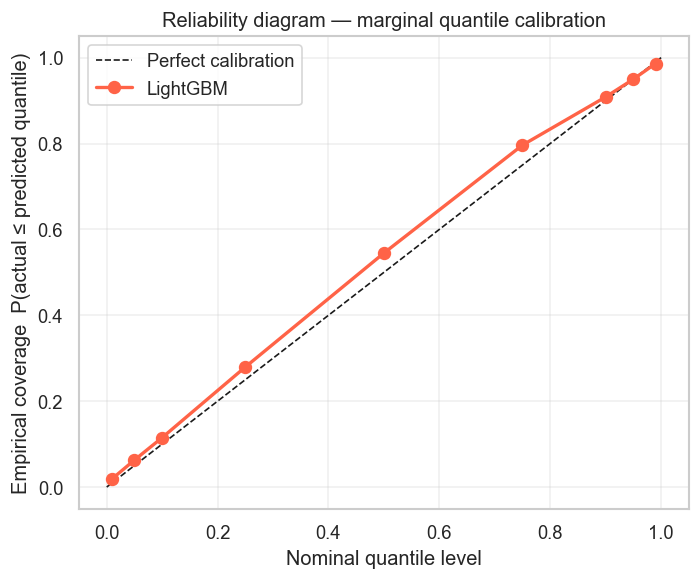

In [31]:
# ── Quantile loss per quantile ────────────────────────────────────────────────

def pinball(y, yhat, q):
    e = y - yhat
    return np.mean(np.where(e >= 0, q * e, (q - 1) * e))

print("Pinball loss per quantile")
print("-" * 35)
pb_losses = []
for q, col in zip(QUANTILES, Q_COLS):
    loss = pinball(actual, results_df[col].values, q)
    pb_losses.append(loss)
    print(f"  Q{int(q*100):02d}: {loss:.3f}")
print(f"  Mean pinball: {np.mean(pb_losses):.3f}")

# ── Coverage & interval width — LightGBM vs naive residual ───────────────────
intervals = [
    ("50%", "pred_q25", "pred_q75"),
    ("80%", "pred_q10", "pred_q90"),
    ("90%", "pred_q05", "pred_q95"),
    ("98%", "pred_q01", "pred_q99"),
]
naive_intervals = [
    ("50%", "naive_q25", "naive_q75"),
    ("80%", "naive_q10", "naive_q90"),
    ("90%", "naive_q05", "naive_q95"),
    ("98%", "naive_q01", "naive_q99"),
]

print("\nCoverage and average interval width: LightGBM vs naive residual")
print("-" * 72)
print(f"{'Interval':8s}  {'Nominal':>8s}  {'LGB cov':>8s}  {'LGB width':>10s}  {'Naive cov':>10s}  {'Naive width':>12s}")
print("-" * 72)
for (label, lgb_lo, lgb_hi), (_, naive_lo, naive_hi) in zip(intervals, naive_intervals):
    lo_lgb    = results_df[lgb_lo].values
    hi_lgb    = results_df[lgb_hi].values
    lo_naive  = results_df[naive_lo].values
    hi_naive  = results_df[naive_hi].values

    lgb_cov    = ((actual >= lo_lgb)   & (actual <= hi_lgb)).mean()   * 100
    naive_cov  = ((actual >= lo_naive) & (actual <= hi_naive)).mean() * 100
    lgb_width  = (hi_lgb   - lo_lgb).mean()
    naive_width = (hi_naive - lo_naive).mean()
    print(f"{label:8s}  {int(label[:-1]):>8d}%  {lgb_cov:>8.1f}%  {lgb_width:>10.2f}  {naive_cov:>10.1f}%  {naive_width:>12.2f}")

# ── Marginal PIT calibration check ───────────────────────────────────────────
# emp = P(actual <= pred_q): fraction of actuals that fall BELOW the predicted quantile.
# Perfect calibration: emp == q.
# emp > q → predicted quantile is too HIGH (level over-forecast)
# emp < q → predicted quantile is too LOW (level under-forecast)

print("\nMarginal PIT calibration (empirical vs nominal quantile coverage)")
print("-" * 70)
print(f"  {'Quantile':>8s}  {'Nominal':>8s}  {'Empirical':>10s}  {'Bias':>8s}  {'Verdict':>25s}")
print("-" * 70)

empirical_coverages = []
for q, col in zip(QUANTILES, Q_COLS):
    emp  = (results_df["actual_price"] <= results_df[col]).mean()
    empirical_coverages.append(emp)
    bias = emp - q
    if abs(bias) < 0.005:
        verdict = "well-calibrated"
    elif bias > 0:
        verdict = "pred too high (over-forecast)"
    else:
        verdict = "pred too low  (under-forecast)"
    print(f"  Q{int(q*100):02d}      {q:>8.3f}  {emp:>10.3f}  {bias:>+8.3f}  {verdict}")

bias_q01 = empirical_coverages[0]  - QUANTILES[0]
bias_q99 = empirical_coverages[-1] - QUANTILES[-1]
print()
if bias_q01 > 0.005 and bias_q99 > 0.005:
    print("  → All quantiles too high: systematic UPWARD LEVEL BIAS in predictions.")
    print("     Lower bound (Q01) is too high, leaving the downside under-covered.")
elif bias_q01 < -0.005 and bias_q99 < -0.005:
    print("  → All quantiles too low: systematic DOWNWARD LEVEL BIAS in predictions.")
elif bias_q01 < -0.005 and bias_q99 > 0.005:
    print("  → Outer quantiles biased outward: marginal intervals TOO WIDE.")
elif bias_q01 > 0.005 and bias_q99 < -0.005:
    print("  → Outer quantiles biased inward: marginal intervals TOO NARROW.")
else:
    print("  → Asymmetric or mixed bias — no single dominant pattern.")

# Reliability diagram
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.plot(QUANTILES, empirical_coverages, "o-", color="tomato", lw=2, ms=7, label="LightGBM")
ax.set_xlabel("Nominal quantile level")
ax.set_ylabel("Empirical coverage  P(actual ≤ predicted quantile)")
ax.set_title("Reliability diagram — marginal quantile calibration")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# ── Shape / ranking diagnostics ───────────────────────────────────────────────

def top_k_overlap(series_actual, series_pred, k, mode="max"):
    """Fraction of top/bottom-k SPs that overlap between actual and predicted."""
    if mode == "max":
        act_set  = set(series_actual.nlargest(k).index)
        pred_set = set(series_pred.nlargest(k).index)
    else:
        act_set  = set(series_actual.nsmallest(k).index)
        pred_set = set(series_pred.nsmallest(k).index)
    return len(act_set & pred_set) / k


daily_diag = []
for date, grp in results_df.groupby("settlement_date"):
    actual_s = grp.set_index("settlement_period")["actual_price"]
    pred_s   = grp.set_index("settlement_period")["pred_q50"]

    if len(grp) < 48:
        continue

    daily_diag.append({
        "date":             date,
        "cheap3_overlap":   top_k_overlap(actual_s, pred_s, 3, mode="min"),
        "peak3_overlap":    top_k_overlap(actual_s, pred_s, 3, mode="max"),
        "min_price_err":    pred_s.min()  - actual_s.min(),
        "max_price_err":    pred_s.max()  - actual_s.max(),
        "spread_err":       (pred_s.max()  - pred_s.min()) - (actual_s.max() - actual_s.min()),
    })

diag_df = pd.DataFrame(daily_diag)

print("Daily shape/ranking diagnostics (aggregated over all test days)")
print("-" * 60)
print(f"  Days evaluated:             {len(diag_df)}")
print(f"  Cheapest-3 SP overlap:      {diag_df['cheap3_overlap'].mean():.2%}")
print(f"  Most-expensive-3 SP overlap:{diag_df['peak3_overlap'].mean():.2%}")
print(f"  Min price error   mean:     {diag_df['min_price_err'].mean():.2f}")
print(f"  Min price error   MAE:      {diag_df['min_price_err'].abs().mean():.2f}")
print(f"  Max price error   mean:     {diag_df['max_price_err'].mean():.2f}")
print(f"  Max price error   MAE:      {diag_df['max_price_err'].abs().mean():.2f}")
print(f"  Spread error      mean:     {diag_df['spread_err'].mean():.2f}")
print(f"  Spread error      MAE:      {diag_df['spread_err'].abs().mean():.2f}")

Daily shape/ranking diagnostics (aggregated over all test days)
------------------------------------------------------------
  Days evaluated:             727
  Cheapest-3 SP overlap:      28.79%
  Most-expensive-3 SP overlap:46.31%
  Min price error   mean:     10.08
  Min price error   MAE:      17.81
  Max price error   mean:     -8.49
  Max price error   MAE:      16.62
  Spread error      mean:     -18.57
  Spread error      MAE:      25.30


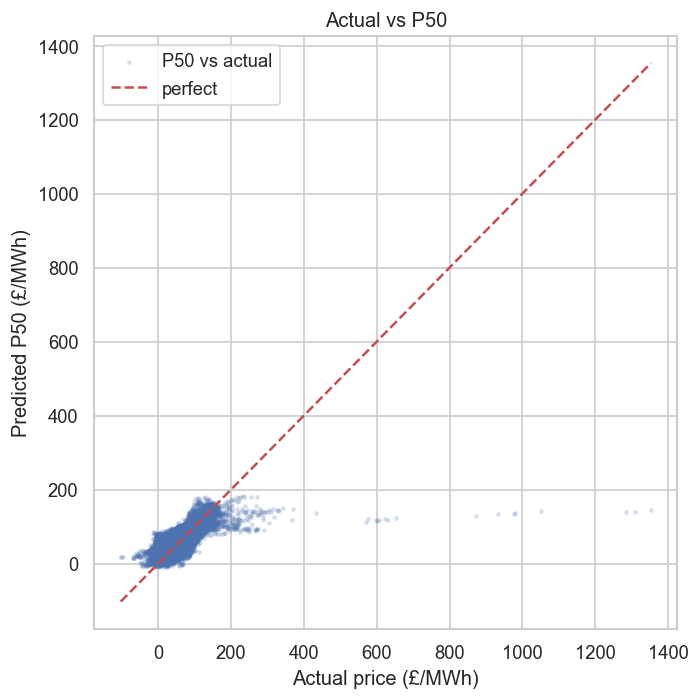

In [33]:
# ── Plots ─────────────────────────────────────────────────────────────────────

# 1. Actual vs P50 scatter
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual, p50, alpha=0.15, s=4, rasterized=True, label="P50 vs actual")
lo, hi = min(actual.min(), p50.min()), max(actual.max(), p50.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="perfect")
ax.set_xlabel("Actual price (£/MWh)")
ax.set_ylabel("Predicted P50 (£/MWh)")
ax.set_title("Actual vs P50")
ax.legend()
plt.tight_layout()
plt.show()

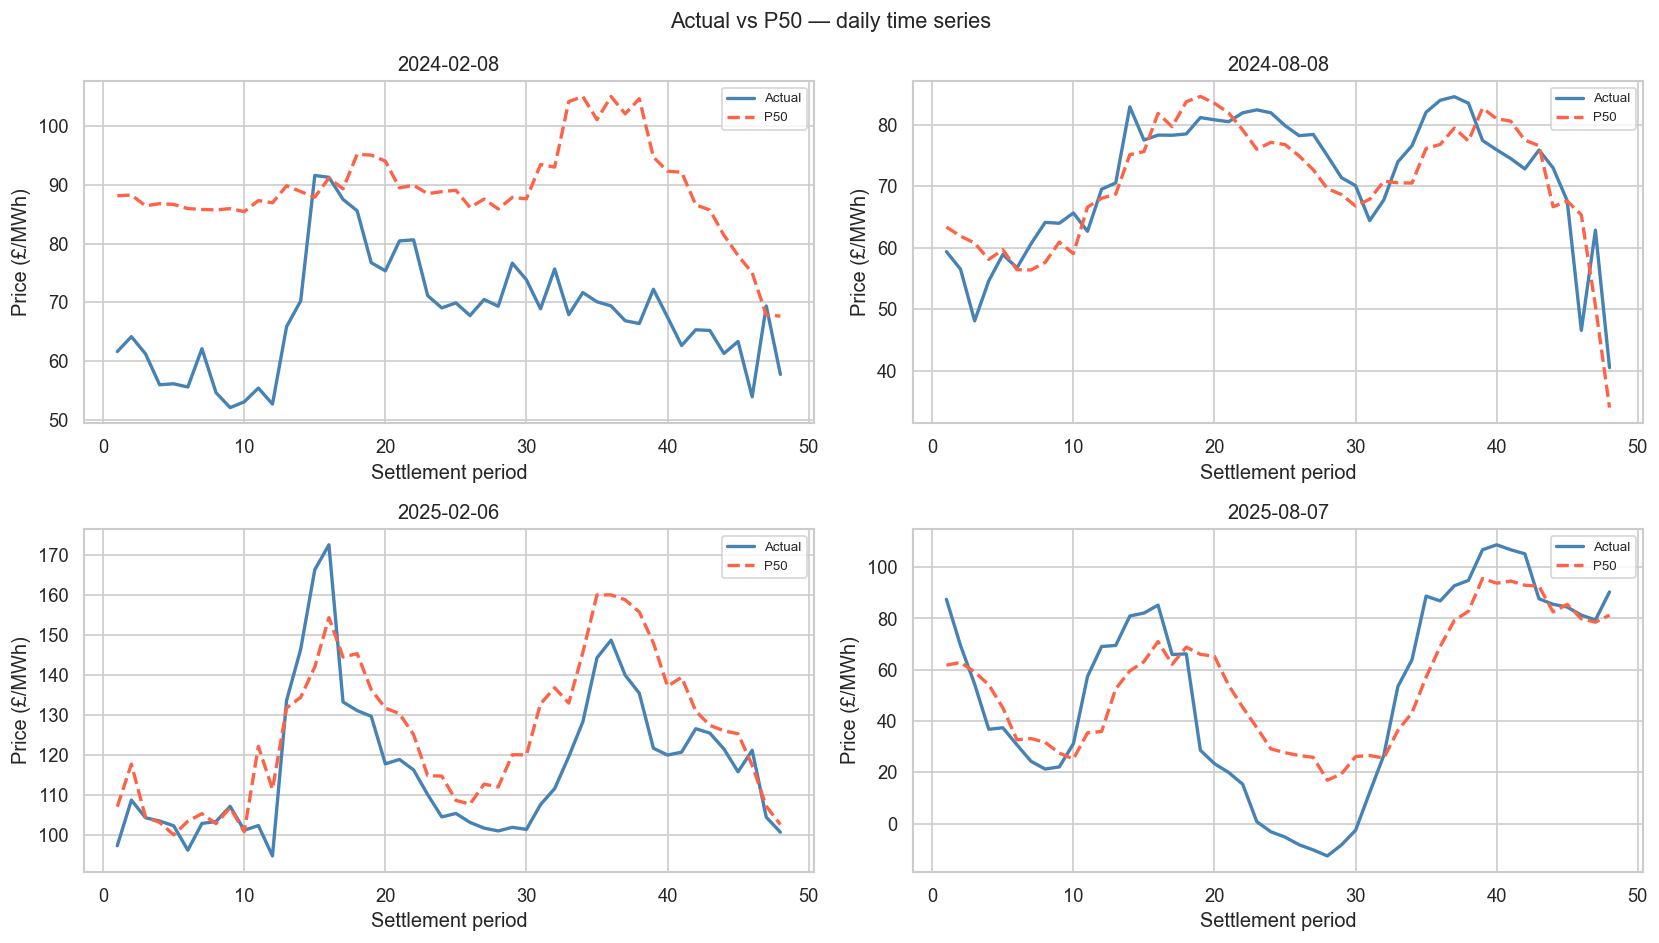

In [34]:
# 2. Daily time-series: actual vs P50  (4 representative days)
sample_dates = results_df.groupby("settlement_date").size()
full_days    = sample_dates[sample_dates == 48].index.tolist()
# Pick days spread across the test window
step = max(1, len(full_days) // 4)
plot_days = full_days[::step][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for ax, date in zip(axes.flat, plot_days):
    day = results_df[results_df["settlement_date"] == date].sort_values("settlement_period")
    sp  = day["settlement_period"]
    ax.plot(sp, day["actual_price"], color="steelblue", lw=2, label="Actual")
    ax.plot(sp, day["pred_q50"],    color="tomato",    lw=2, linestyle="--", label="P50")
    ax.set_title(str(date.date()))
    ax.set_xlabel("Settlement period")
    ax.set_ylabel("Price (£/MWh)")
    ax.legend(fontsize=8)
fig.suptitle("Actual vs P50 — daily time series", fontsize=13)
plt.tight_layout()
plt.show()

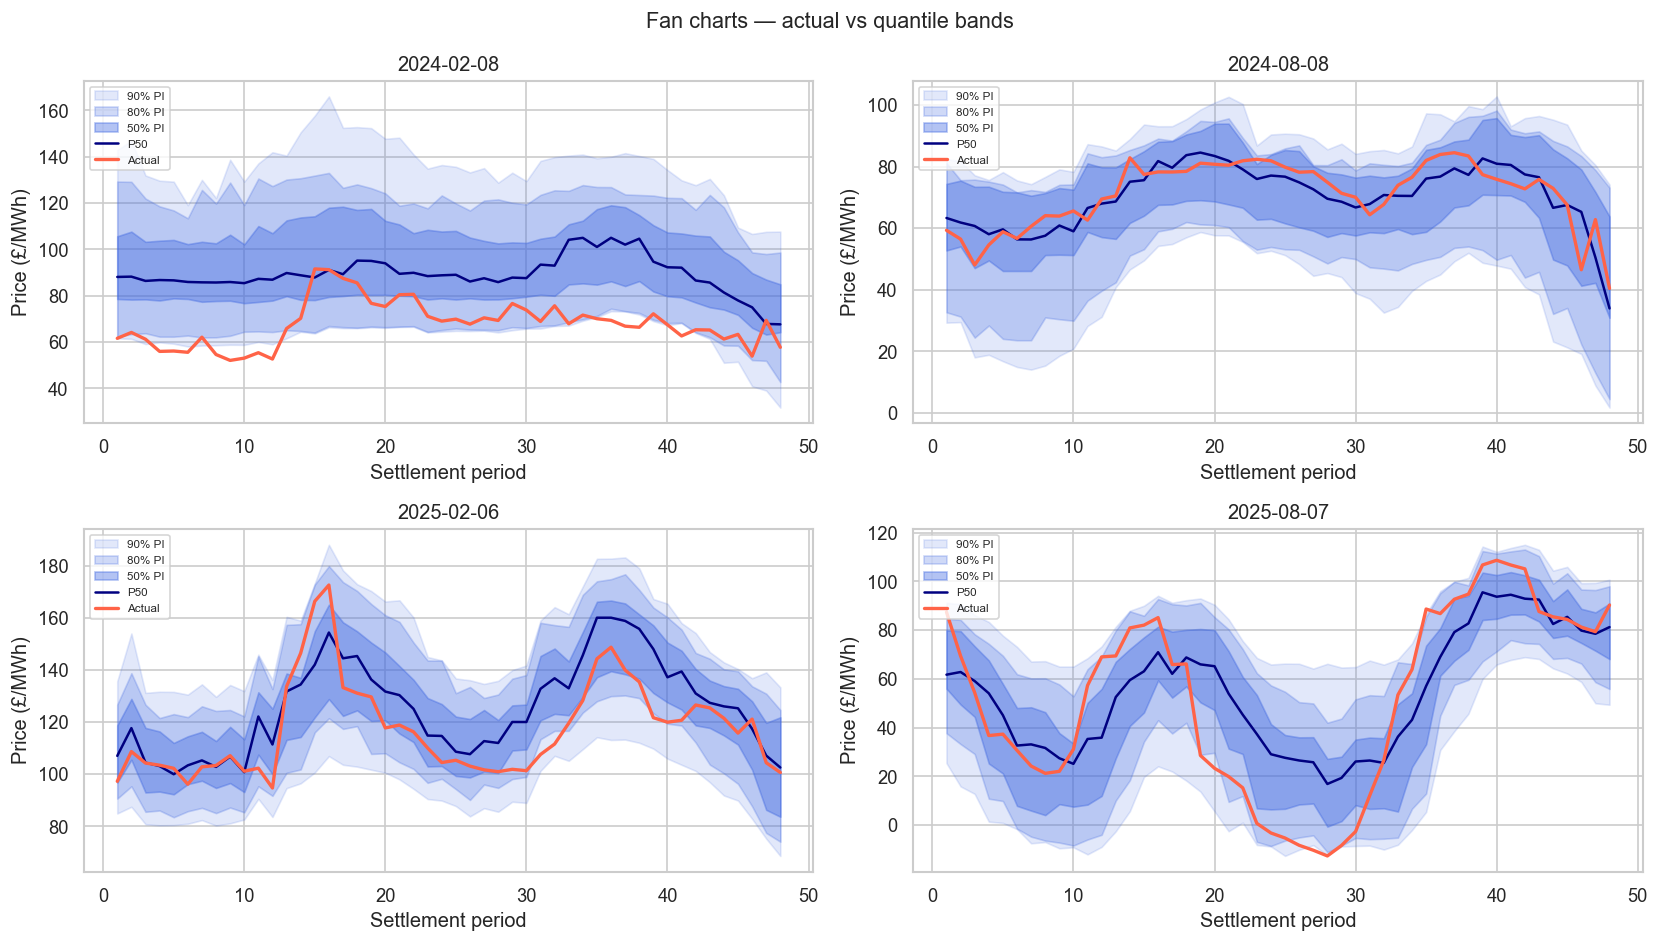

In [35]:
# 3. Fan charts: actual + P50 + quantile bands (4 days)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for ax, date in zip(axes.flat, plot_days):
    day = results_df[results_df["settlement_date"] == date].sort_values("settlement_period")
    sp  = day["settlement_period"]
    ax.fill_between(sp, day["pred_q05"], day["pred_q95"], alpha=0.15, color="royalblue", label="90% PI")
    ax.fill_between(sp, day["pred_q10"], day["pred_q90"], alpha=0.25, color="royalblue", label="80% PI")
    ax.fill_between(sp, day["pred_q25"], day["pred_q75"], alpha=0.40, color="royalblue", label="50% PI")
    ax.plot(sp, day["pred_q50"],    color="navy",     lw=1.5, label="P50")
    ax.plot(sp, day["actual_price"], color="tomato",  lw=2,   label="Actual")
    ax.set_title(str(date.date()))
    ax.set_xlabel("Settlement period")
    ax.set_ylabel("Price (£/MWh)")
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Fan charts — actual vs quantile bands", fontsize=13)
plt.tight_layout()
plt.show()

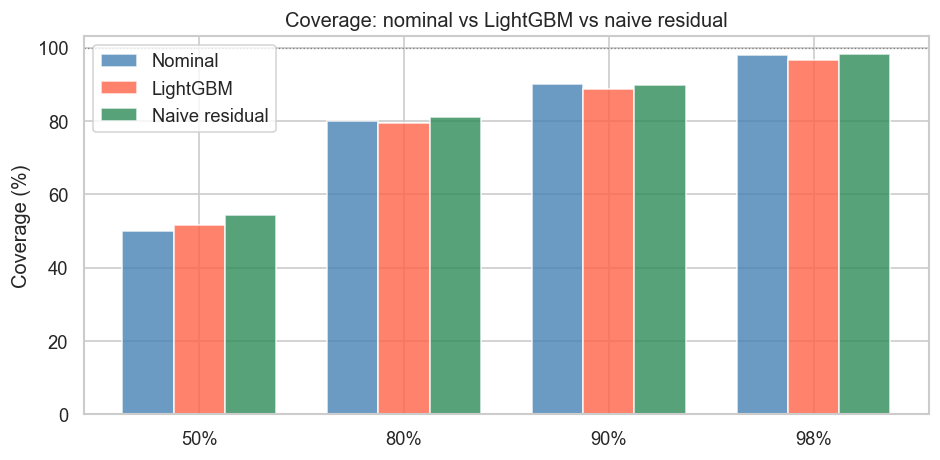

In [37]:
# 4. Coverage comparison: nominal vs LightGBM vs naive residual
nominal_levels = [50, 80, 90, 98]
lgb_cov_list   = []
naive_cov_list = []

for (label, lgb_lo, lgb_hi), (_, naive_lo, naive_hi) in zip(intervals, naive_intervals):
    lo_lgb   = results_df[lgb_lo].values
    hi_lgb   = results_df[lgb_hi].values
    lo_naive = results_df[naive_lo].values
    hi_naive = results_df[naive_hi].values
    lgb_cov_list.append(((actual >= lo_lgb)   & (actual <= hi_lgb)).mean()   * 100)
    naive_cov_list.append(((actual >= lo_naive) & (actual <= hi_naive)).mean() * 100)

x = np.arange(len(nominal_levels))
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w,   nominal_levels,  w, label="Nominal",        color="steelblue", alpha=0.8)
ax.bar(x,       lgb_cov_list,    w, label="LightGBM",        color="tomato",    alpha=0.8)
ax.bar(x + w,   naive_cov_list,  w, label="Naive residual",  color="seagreen",  alpha=0.8)
ax.axhline(100, ls=":", color="grey", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{n}%" for n in nominal_levels])
ax.set_ylabel("Coverage (%)")
ax.set_title("Coverage: nominal vs LightGBM vs naive residual")
ax.legend()
plt.tight_layout()
plt.show()


/var/folders/s7/5nwl8nq153g7l5yprlh9jbw00000gn/T/ipykernel_70999/2596298509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=width_df, x="Interval", y="Width", ax=ax, palette="Set2", inner="quartile")


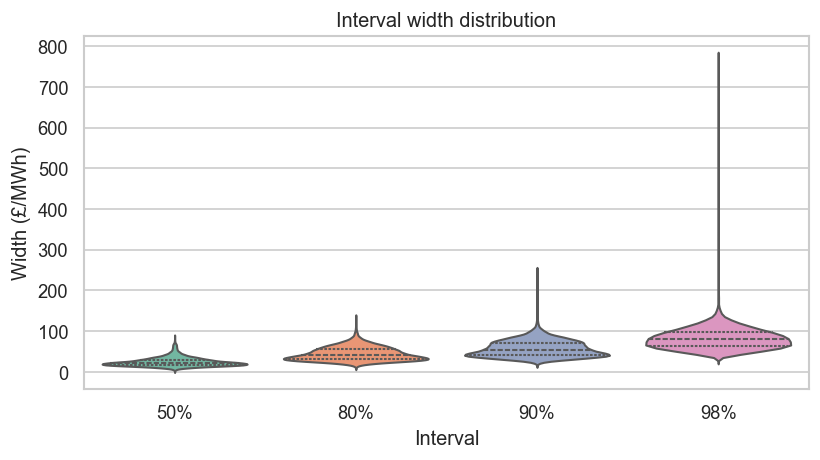

In [38]:
# 5. Interval width distribution (violin per interval level)
width_data = []
for label, lo_col, hi_col in intervals:
    widths = results_df[hi_col].values - results_df[lo_col].values
    width_data.extend([(label, w) for w in widths])
width_df = pd.DataFrame(width_data, columns=["Interval", "Width"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=width_df, x="Interval", y="Width", ax=ax, palette="Set2", inner="quartile")
ax.set_title("Interval width distribution")
ax.set_ylabel("Width (£/MWh)")
plt.tight_layout()
plt.show()

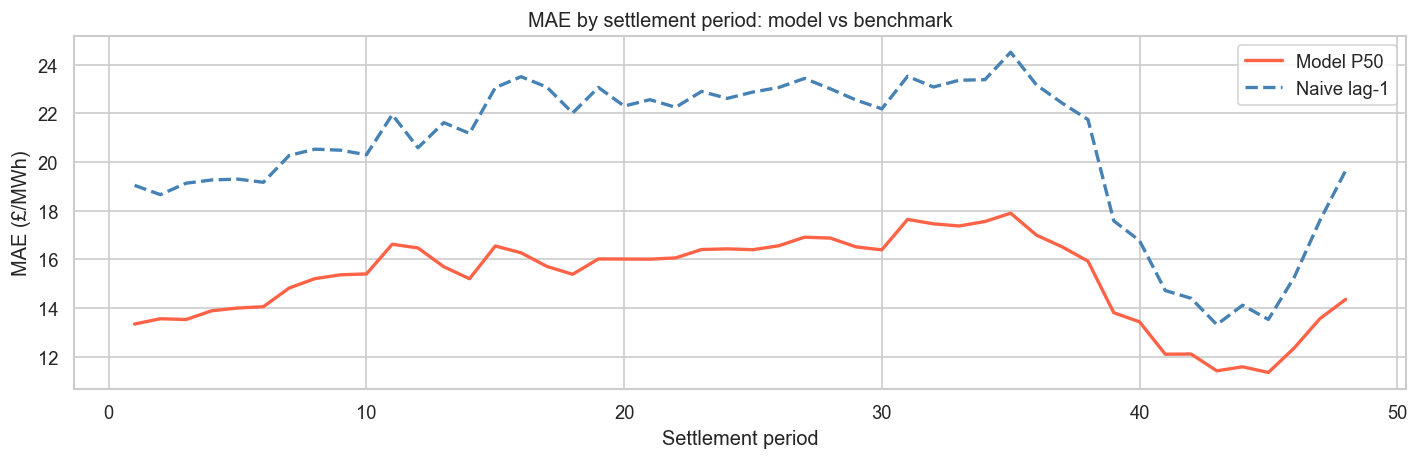

In [39]:
# 6. MAE by settlement period: model vs benchmark
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(by_sp["settlement_period"], by_sp["model_mae"],  label="Model P50", color="tomato",    lw=2)
ax.plot(by_sp["settlement_period"], by_sp["naive_mae"],  label="Naive lag-1", color="steelblue", lw=2, linestyle="--")
ax.set_xlabel("Settlement period")
ax.set_ylabel("MAE (£/MWh)")
ax.set_title("MAE by settlement period: model vs benchmark")
ax.legend()
plt.tight_layout()
plt.show()

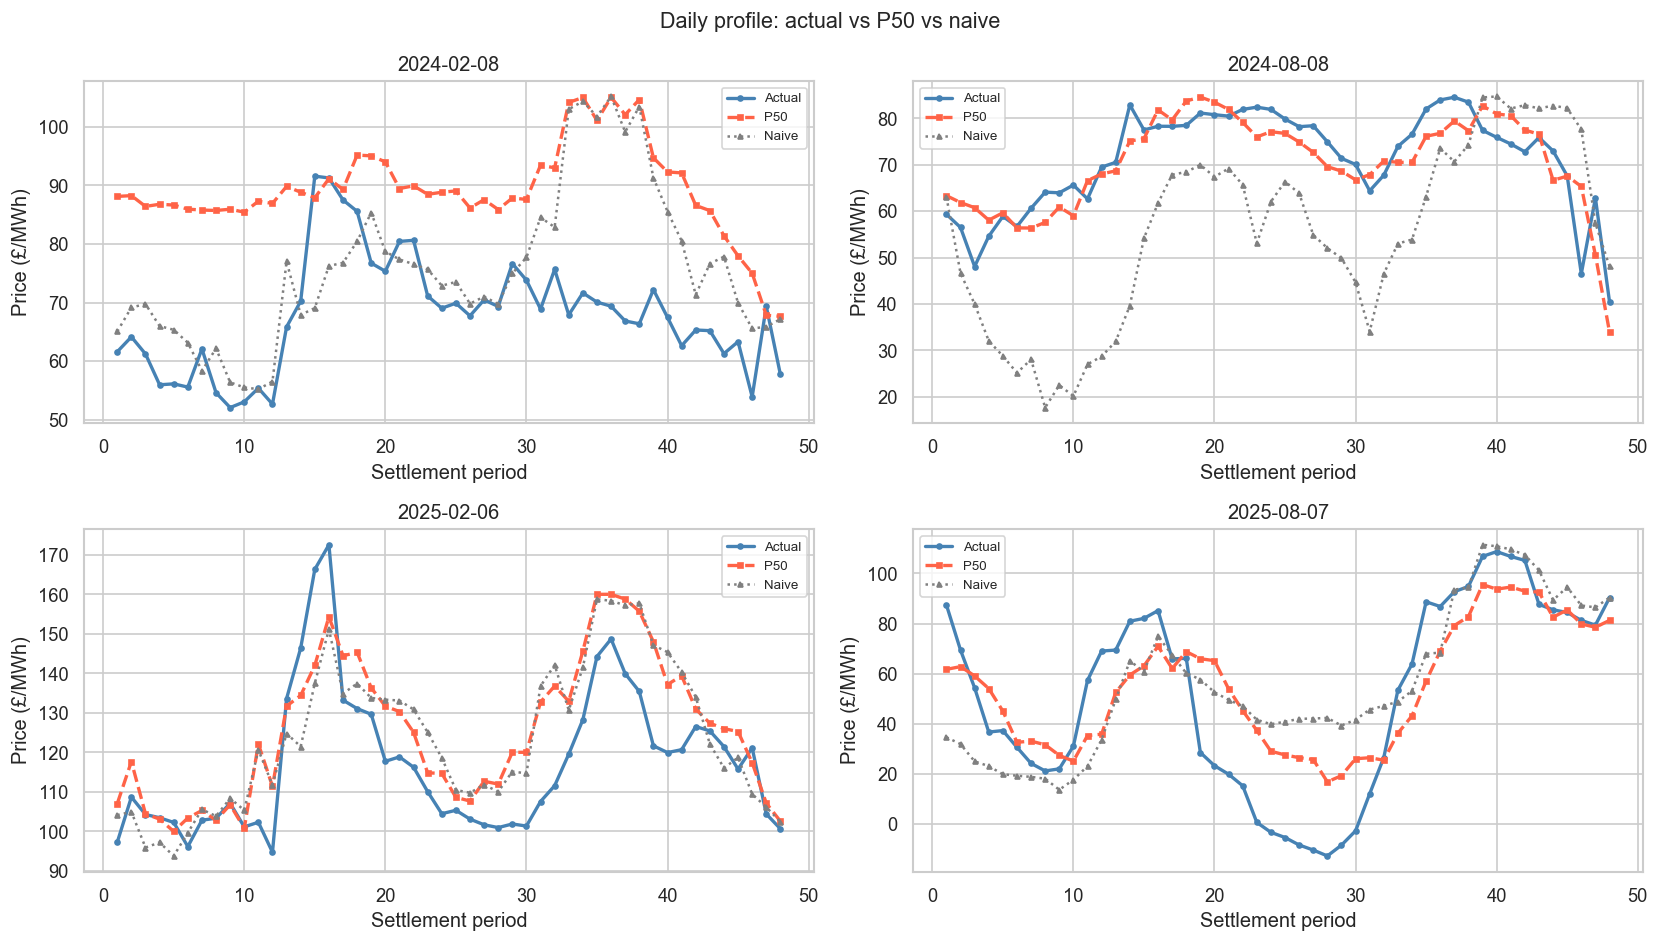

In [40]:
# 7. Daily profile comparisons: actual vs predicted shape (4 days)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for ax, date in zip(axes.flat, plot_days):
    day = results_df[results_df["settlement_date"] == date].sort_values("settlement_period")
    sp  = day["settlement_period"]
    ax.plot(sp, day["actual_price"], color="steelblue", lw=2,   marker="o", ms=3, label="Actual")
    ax.plot(sp, day["pred_q50"],    color="tomato",    lw=2,   marker="s", ms=3, linestyle="--", label="P50")
    ax.plot(sp, day["naive_forecast"], color="grey",   lw=1.5, marker="^", ms=3, linestyle=":",  label="Naive")
    ax.set_title(str(date.date()))
    ax.set_xlabel("Settlement period")
    ax.set_ylabel("Price (£/MWh)")
    ax.legend(fontsize=8)
fig.suptitle("Daily profile: actual vs P50 vs naive", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

### Point forecast
The model **P50 beats the lag-1 naive benchmark overall** with meaningful MAE and RMSE improvements. The gain is consistent across most months and settlement periods. The exception is **February and March**, where the naive benchmark outperforms the model — in periods of low day-over-day volatility, the simple lag-1 forecast is hard to beat.

### Probabilistic calibration vs naive residual baseline
LightGBM intervals are better calibrated **and considerably more efficient** than the naive residual baseline at all levels (50%, 80%, 90%, 98%). The naive residual interval applies a fixed global offset regardless of time of day or supply conditions; LightGBM adapts to context, achieving similar coverage at roughly half the interval width at the 80%/90% level.

The 98% interval (Q01–Q99) is the key addition for the copula scenario generator: it directly anchors the inverse CDF tail, replacing dangerous linear extrapolation from Q05/Q95 with a fitted model value that covers 98% of the uniform draw range before any extrapolation is needed.

### Marginal PIT calibration
The reliability diagram and PIT table show whether each quantile is correctly positioned. A consistent upward bias across all quantiles (empirical > nominal) indicates the model over-forecasts prices — the entire distribution is shifted up relative to reality. This is a **level bias**, not a width problem, and does not indicate that intervals are too wide.

### Quantile crossing
Crossings are concentrated at the tail pairs (Q01/Q05 and Q95/Q99) as expected — tail quantiles are harder to order when trained independently. All crossings are corrected by row-wise sorting before saving.

### Shape / ranking diagnostics
The model predicts **daily spread and extremes with systematic bias**:
- **Spread is compressed**: the model under-predicts the daily high and over-predicts the daily low on average.
- **Cheapest-3 SP identification is weak** (~29% overlap) — off-peak timing is structurally less predictable.
- **Peak-3 SP identification is moderate** (~46% overlap) — evening peaks are more predictable from settlement period and demand features.

### Main weaknesses
- **Spread compression in point forecasts**: the P50 daily range is narrower than actual, limiting direct dispatch value from point forecasts alone. Probabilistic scenarios (via the copula) are the right tool for this.
- **Feb/Mar regime sensitivity**: the model is beaten by naive in periods of sticky day-over-day prices.
- **Deep tail calibration (Q01/Q99)**: these are new and may be harder to calibrate with limited extreme price observations. Check their PIT bias in the reliability diagram.

In [41]:
results_df.to_parquet("data/processed/lightgbm_quantile.parquet")